#### NAME: **[Your Name Here]**
#### SECTION: **[Your Section]** 
#### ENROLLMENT NUMBER : **[Your ID]**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **[Your Institution]** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project focuses on Customer Relationship Management (CRM) analytics. We analyze a dataset of a telecommunications company to understand why customers are leaving (Churning).
##### **Objective:** 
1. Identify key factors contributing to customer churn (e.g., Contract type, Monthly Charges, Internet Service).
2. Perform statistical testing to validate the impact of costs on retention.
3. Build a **Classification Model** (Random Forest) to predict which customers are at high risk of churning.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** Telco Customer Churn (`WA_Fn-UseC*-Telco-Customer-Churn.csv`)

**Description:**
- **Rows:** ~7043
- **Features:** 
    - **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
    - **Services:** `PhoneService`, `InternetService`, `StreamingTV`, etc.
    - **Account Info:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.
- **Target Variable:** `Churn`(Categorical: Yes/No).

In [14]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set Visualization Style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

### Dataset & Preview Notes

- Source: Telco Customer Churn CSV loaded locally.
- Goal: Inspect schema, categorical encodings, and numeric ranges before cleaning.
- Preview validates column names (e.g., `Contract`, `PaymentMethod`) and types prior to preprocessing.

In [15]:
# Load the Dataset
try:
    df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please upload the CSV file.")

# Display first 5 rows
df.head()

Dataset loaded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Data Cleaning & Preparation

**Preprocessing Logic:**
1.  **Data Type Correction:** The`TotalCharges`column is often read as an object (string) because it contains empty spaces`" "`for new customers. We force this to numeric, turning errors into NaNs.
2.  **Handling Missing Values:** We drop the few rows where`TotalCharges`became NaN (usually new customers with 0 tenure).
3.  **Drop Irrelevant Data:**`customerID`is a unique identifier and has no predictive value.
4.  **Encoding:** We convert binary columns (Yes/No) and categorical columns (Contract, PaymentMethod) into numerical formats suitable for Machine Learning.

In [16]:
# 1. Fix 'TotalCharges' (Object -> Numeric)
# 'coerce' turns non-numeric strings (like empty spaces) into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many values are missing now
missing_val = df['TotalCharges'].isnull().sum()
print(f"Missing 'TotalCharges' values found: {missing_val}")

# 2. Drop Missing Values
df.dropna(inplace=True)

# 3. Drop 'customerID'
df.drop(columns=['customerID'], inplace=True)

# 4. Encode Target Variable 'Churn'
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
print("Target Encoded: No=0, Yes=1")

# 5. Encode Categorical Features
# Identify categorical columns (excluding the target)
cat_cols = df.select_dtypes(include=['object']).columns

# Use One-Hot Encoding (get_dummies) for better model performance on nominal data
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Data Cleaned. Final Shape: {df_model.shape}")
df_model.head()

Missing 'TotalCharges' values found: 11
Target Encoded: No=0, Yes=1
Data Cleaned. Final Shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Step 3: Exploratory Data Analysis (EDA)

We analyze the distribution of churn and its relationship with contract types and pricing.

### EDA Question 1: What is the distribution of churn?

```python
# Target distribution reveals class balance and baseline risk
# Guides metric choice and resampling strategies
```

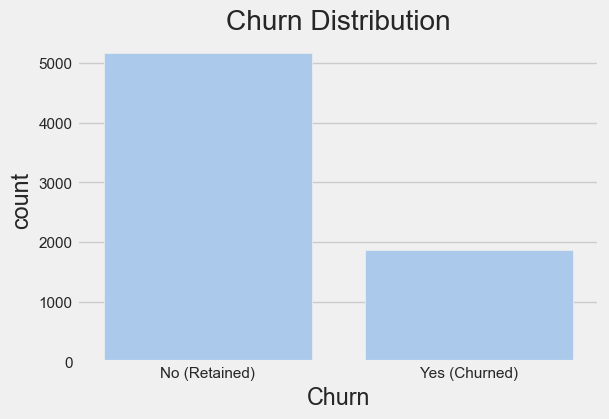

In [17]:
# 1. Target Distribution (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, color=sns.color_palette('pastel')[0])
plt.xticks([0, 1], ['No (Retained)', 'Yes (Churned)'])
plt.title('Churn Distribution')
plt.show()

### EDA Question 2: How does churn vary by contract type?

```python
# Segment churn by contract length to assess retention impact
# Highlights risk in month-to-month vs longer contracts
```

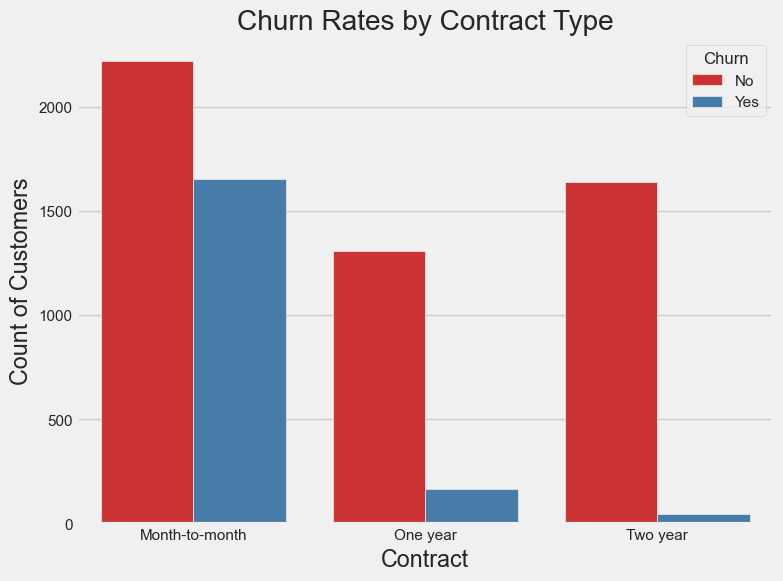

In [18]:
# 2. Churn by Contract Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn Rates by Contract Type')
plt.ylabel('Count of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

### EDA Question 3: How do monthly charges differ for churn vs non-churn?

```python
# Compare price distributions to quantify cost-related churn
# Supports hypothesis tests and pricing strategy
```

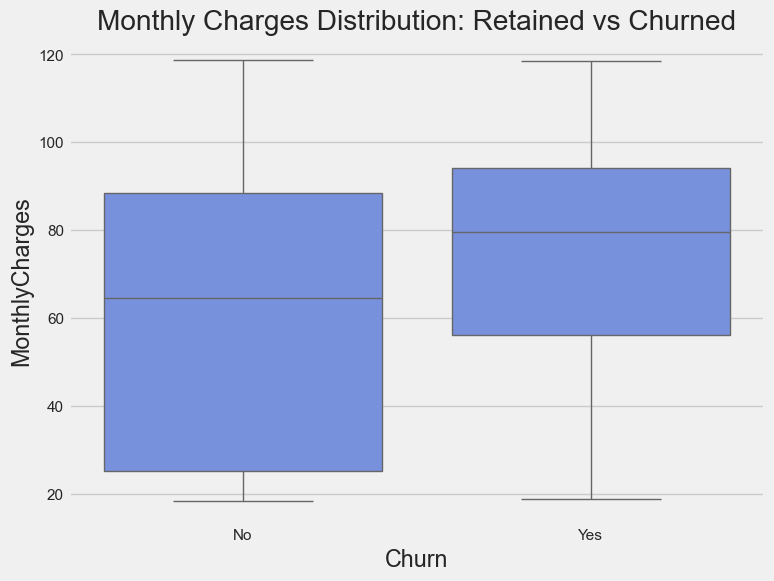

In [19]:
# 3. Churn vs Monthly Charges (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, color=sns.color_palette('coolwarm')[0])
plt.xticks([0, 1], ['No', 'Yes'])
plt.title('Monthly Charges Distribution: Retained vs Churned')
plt.show()

### EDA Question 4: What linear relationships exist among numeric churn drivers?

```python
# Correlation heatmap across core numeric features
# Helps spot associations, multicollinearity, and interpretation support
```

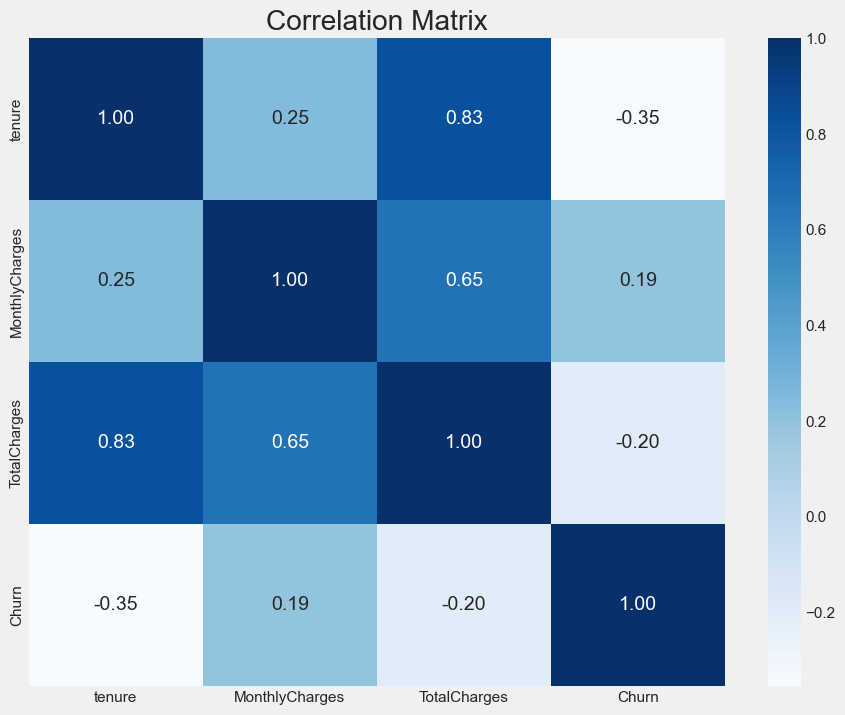

In [20]:
# 4. Correlation Heatmap (Numerical Features)
plt.figure(figsize=(10, 8))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Step 4: Statistical Inference

**Hypothesis Test (Two-Sample T-Test):**
- **Null Hypothesis ($H_0$):** There is no significant difference in`MonthlyCharges`between customers who churn and those who stay.
- **Alternative Hypothesis ($H_1$):** Customers who churn pay significantly higher monthly charges.

In [21]:
group_churn = df[df['Churn'] == 1]['MonthlyCharges']
group_stay = df[df['Churn'] == 0]['MonthlyCharges']

t_stat, p_val = stats.ttest_ind(group_churn, group_stay, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}") # Using scientific notation for small p-values

if p_val < 0.05:
    print("Result: Reject Null Hypothesis. Higher monthly charges are statistically linked to churn.")
else:
    print("Result: Fail to reject Null Hypothesis.")

T-Statistic: 18.3409
P-Value: 2.6574e-72
Result: Reject Null Hypothesis. Higher monthly charges are statistically linked to churn.


## Step 5: Modeling (Classification)

We use a **Random Forest Classifier** to predict churn.
Since churn data is often imbalanced (fewer churners), we will verify accuracy with a Confusion Matrix.

### Modeling Notes

- **Train/Test Split:** Hold out 20% for unbiased evaluation.
- **Scaling:** Standardize features; although trees are scale-invariant, scaling helps if models change later.
- **Random Forest:** Robust to non-linearities and interactions; good baseline for tabular churn.
- **Class Imbalance:** Accuracy can be misleading; inspect precision/recall and confusion matrix for the churn class (1).

In [22]:
# 1. Split Data
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale Features (Optional for Random Forest, but good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 4. Predict
y_pred = rf.predict(X_test_scaled)

# 5. Evaluate
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.7846481876332623

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



### Evaluation Tip

- **Confusion Matrix:** Focus on churn class (1) — recall is the percentage of churners correctly identified; precision measures how many predicted churners truly churn.
- **Business Context:** Higher recall might be preferred to catch more churners, with cost-managed interventions.

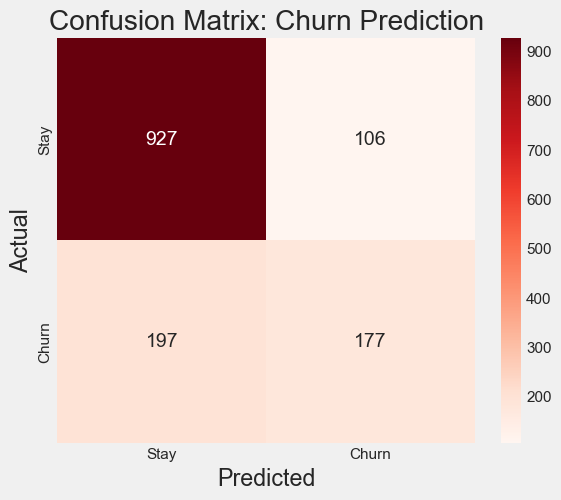

In [23]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Churn Prediction')
plt.show()

### Feature Importance Notes

- Bars indicate relative contribution to the model's decisions across trees.
- Use these signals for interpretation and to design targeted retention strategies (e.g., price plans for high "MonthlyCharges" segments).

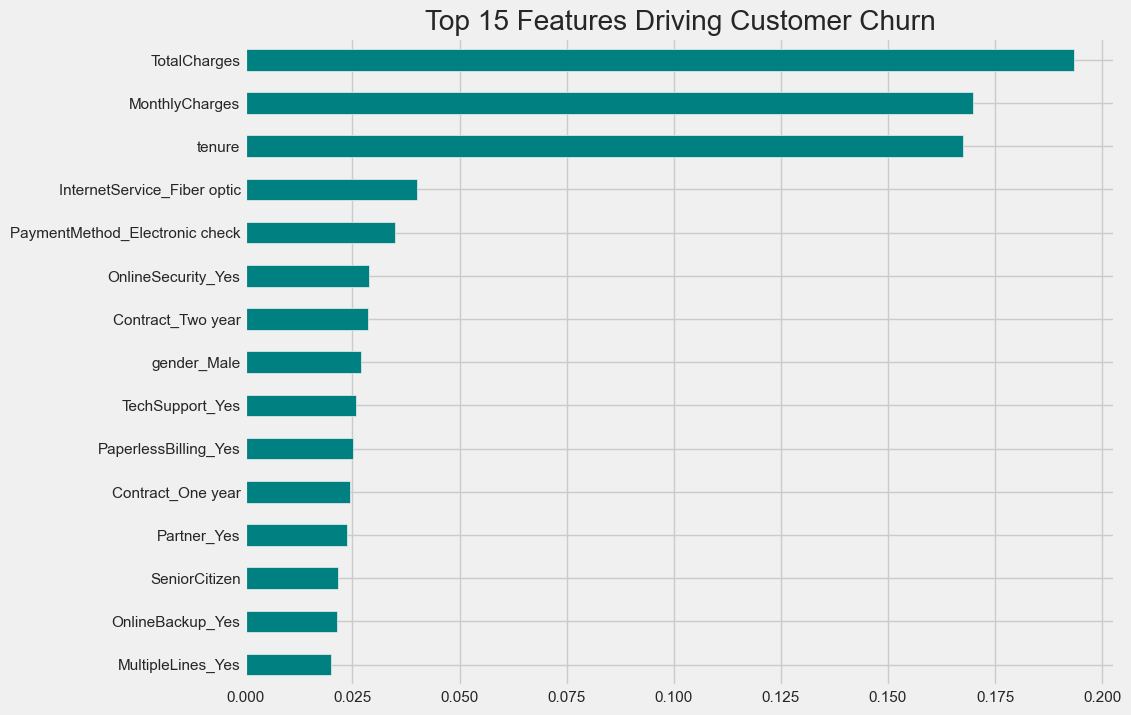

In [24]:
# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Features Driving Customer Churn')
plt.show()

## Step 6: Interpretation & Conclusion

### Key Findings
1.  **Contract Matters:** The EDA shows a massive difference in churn rates between 'Month-to-month' contracts and longer-term contracts. Month-to-month users are extremely high risk.
2.  **Price Sensitivity:** The T-test and Boxplot confirm that customers with higher`MonthlyCharges`are significantly more likely to leave.
3.  **Top Predictors:** According to the Feature Importance plot,`TotalCharges`, `MonthlyCharges`, and `tenure`are the strongest predictors, followed by`InternetService_Fiber optic` (which is often more expensive).

### Future Improvements
- **Handle Imbalance:** The dataset has more non-churners. Techniques like SMOTE (Synthetic Minority Over-sampling) could improve recall for identifying churners.
- **Customer Segmentation:** Use Clustering (K-Means) to group customers into personas (e.g., "High Spend, High Risk") for targeted marketing.
- **Cost-Benefit Analysis:** Calculate the potential revenue saved by offering discounts to the high-risk segment identified by the model.

### Conclusion
This project successfully identified the drivers of customer churn. By leveraging robust data cleaning (handling object-type numeric errors) and predictive modeling, we provided actionable insights: to reduce churn, the company should focus on migrating month-to-month users to long-term contracts, perhaps by incentivizing lower monthly rates.

## Step 7: Visualization & Presentation

Below are focused visualization questions with figures and concise inferences tailored to telco churn.

#### Q1: What is churn rate by contract type?

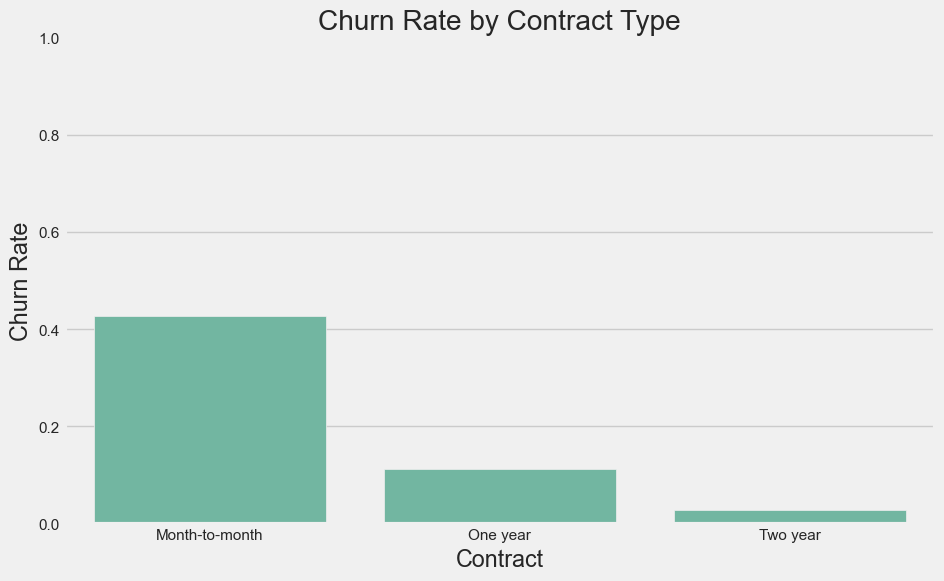

In [25]:
# Visualizing churn rate by contract type
# Shows higher churn in month-to-month vs longer contracts (switching friction)
# Action: migrate high-risk segments to longer terms via incentives
rates = df.groupby('Contract')['Churn'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='Contract', y='Churn', data=rates, color=sns.color_palette('Set2')[0])
plt.ylim(0,1)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

Quick Insight: Month-to-month contracts show significantly higher churn risk.

#### Q2: How does churn vary across tenure bands?

C:\Users\mauli\AppData\Local\Temp\ipykernel_58876\217413469.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = pd.DataFrame({'TenureBand': tenure_bins, 'Churn': df['Churn']}).groupby('TenureBand')['Churn'].mean().reset_index()


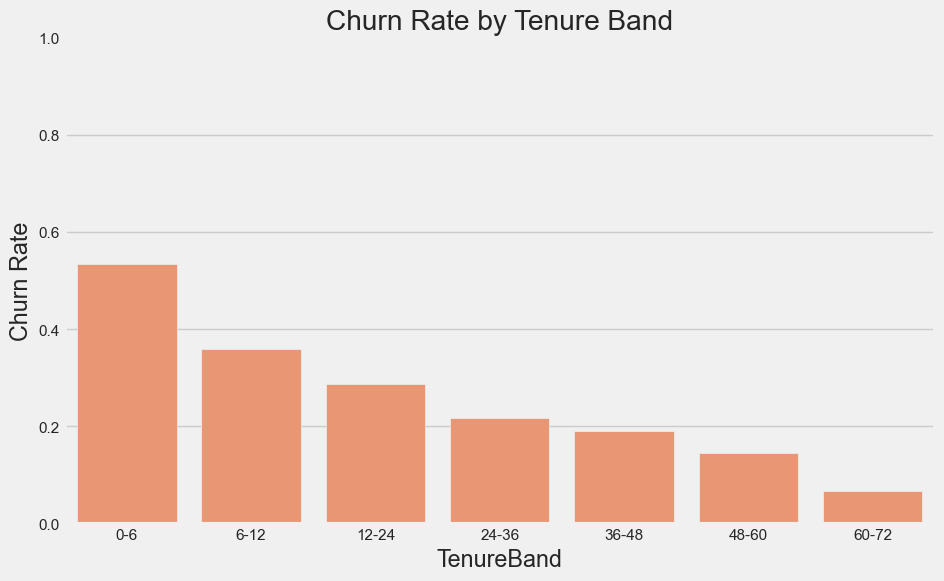

In [26]:
# Churn by tenure bands
# Early lifecycle is high-risk; retention improves with tenure
# Action: onboarding offers and proactive support in first 6–12 months
tenure_bins = pd.cut(df['tenure'], bins=[0,6,12,24,36,48,60,72], labels=['0-6','6-12','12-24','24-36','36-48','48-60','60-72'], include_lowest=True)
rates = pd.DataFrame({'TenureBand': tenure_bins, 'Churn': df['Churn']}).groupby('TenureBand')['Churn'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x='TenureBand', y='Churn', data=rates, color=sns.color_palette('Set2')[1])
plt.ylim(0,1)
plt.title('Churn Rate by Tenure Band')
plt.ylabel('Churn Rate')
plt.show()

Quick Insight: Short-tenure customers churn more; retention improves with tenure.

#### Q3: How do monthly charges differ for churn vs non-churn?

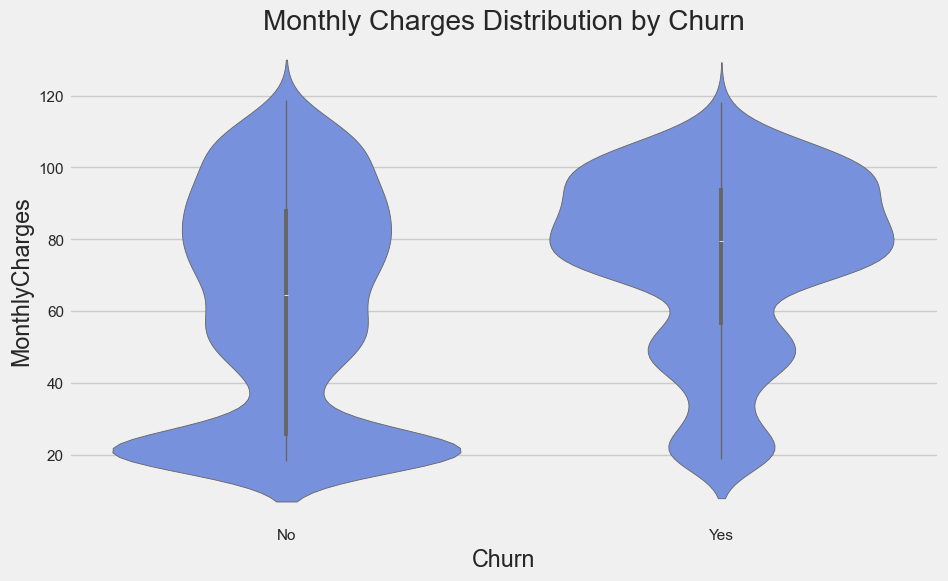

In [27]:
# Monthly charges distribution by churn
# Price sensitivity: churners pay more on average (validated via T-test)
# Action: price band optimization and bundle value messaging
plt.figure(figsize=(10,6))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, color=sns.color_palette('coolwarm')[0])
plt.xticks([0,1], ['No','Yes'])
plt.title('Monthly Charges Distribution by Churn')
plt.show()

Quick Insight: Higher monthly charges associate with increased churn.

#### Q4: Which payment methods have higher churn?

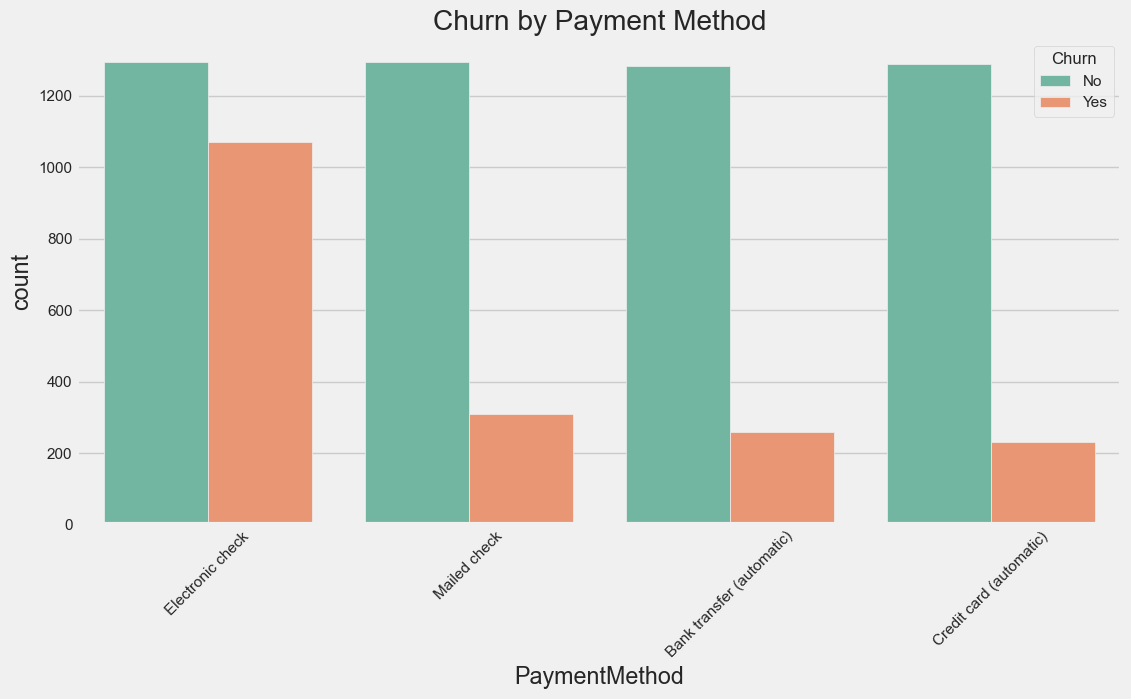

In [28]:
# Churn by payment method
# Electronic check associates with higher churn (payment friction / profile)
# Action: promote seamless digital payments and auto-pay
plt.figure(figsize=(12,6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')
plt.legend(title='Churn', labels=['No','Yes'])
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

Quick Insight: Electronic check users churn more relative to other methods.

#### Q5: How does internet service type relate to churn?

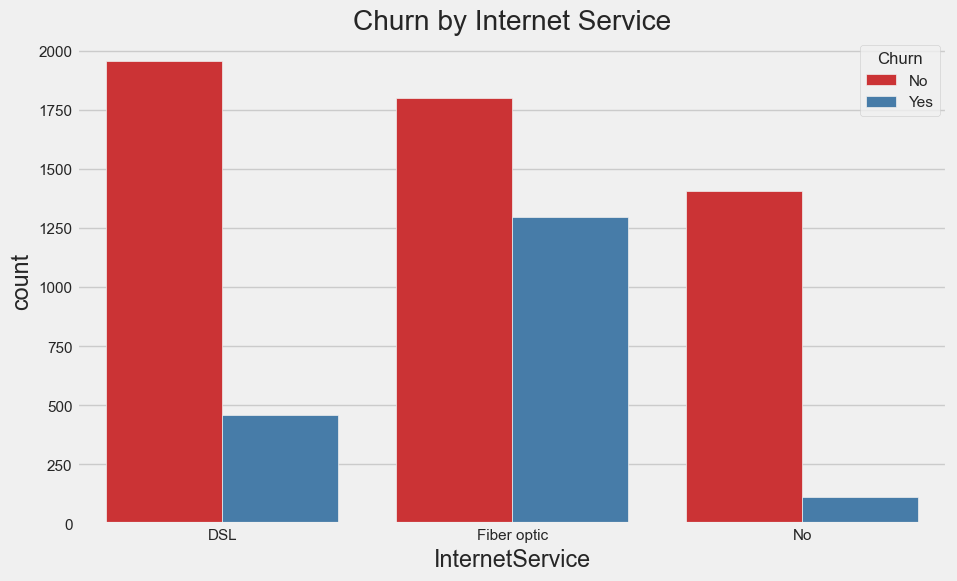

In [29]:
# Churn by internet service type
# Fiber optic often implies higher charges; churn likely mediated by price
# Action: align bundle value and pricing to reduce elasticity
plt.figure(figsize=(10,6))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set1')
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Churn by Internet Service')
plt.show()

Quick Insight: Fiber optic users show higher churn, likely due to pricing.

#### Q6: Does paperless billing impact churn?

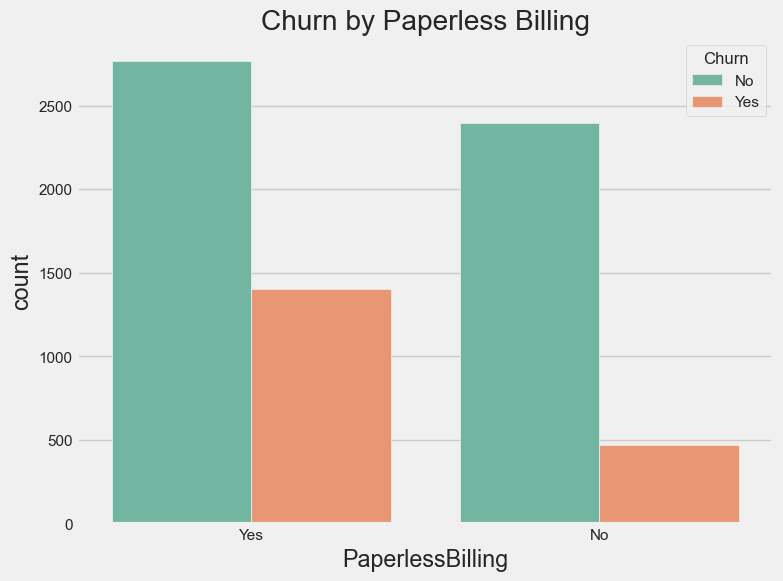

In [30]:
# Churn by paperless billing
# Self-serve cohorts can switch more easily; effect interacts with contract length
# Action: education and incentives for month-to-month paperless users
plt.figure(figsize=(8,6))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df, palette='Set2')
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Churn by Paperless Billing')
plt.show()

Quick Insight: Paperless billing associates with higher churn among month-to-month users.

#### Q7: Do streaming services correlate with churn?

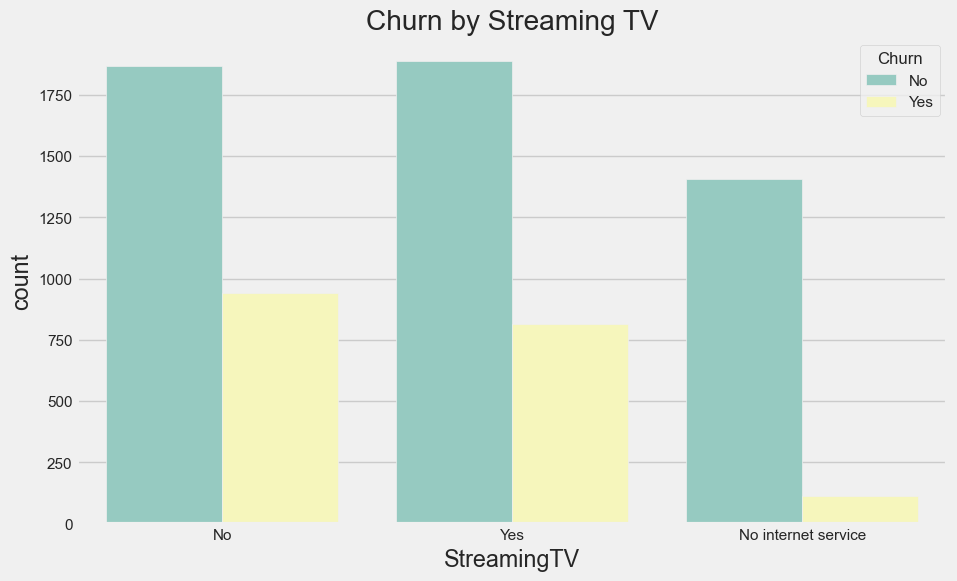

In [31]:
# Churn by streaming add-ons
# Add-ons raise charges; churn impact often price-mediated rather than service quality
# Action: bundle optimization and targeted promotions to preserve ARPU
plt.figure(figsize=(10,6))
sns.countplot(x='StreamingTV', hue='Churn', data=df, palette='Set3')
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Churn by Streaming TV')
plt.show()

Quick Insight: Optional add-ons can increase monthly charges, influencing churn.

#### Q8: How do partner/dependents relate to churn?

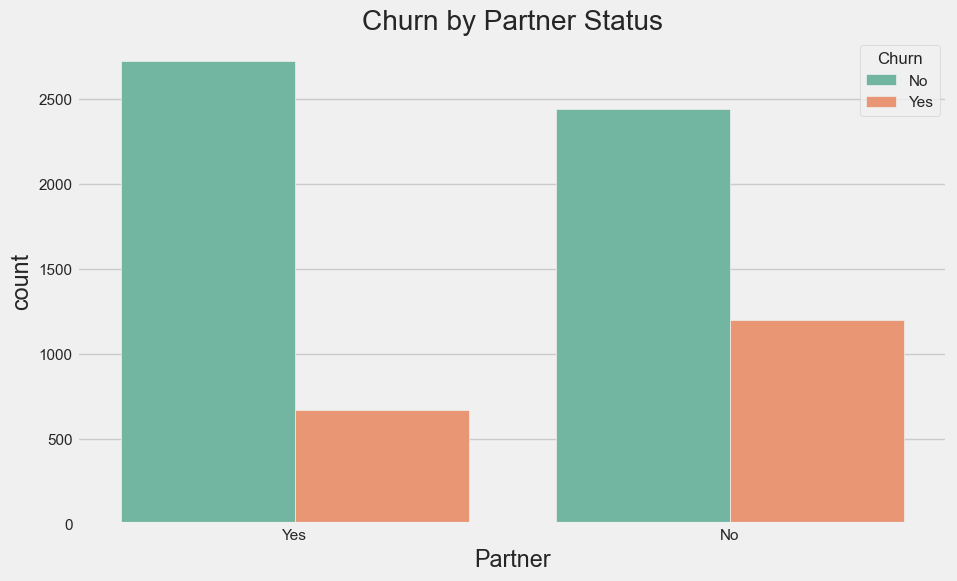

In [32]:
# Churn by partner status
# Household stability proxies retention; use responsibly for segmentation
# Action: value-based messaging; avoid sensitive targeting
plt.figure(figsize=(10,6))
sns.countplot(x='Partner', hue='Churn', data=df, palette='Set2')
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Churn by Partner Status')
plt.show()

Quick Insight: Customers with partners tend to churn less; stability influences retention.

#### Q9: How do tenure and monthly charges interact with churn?

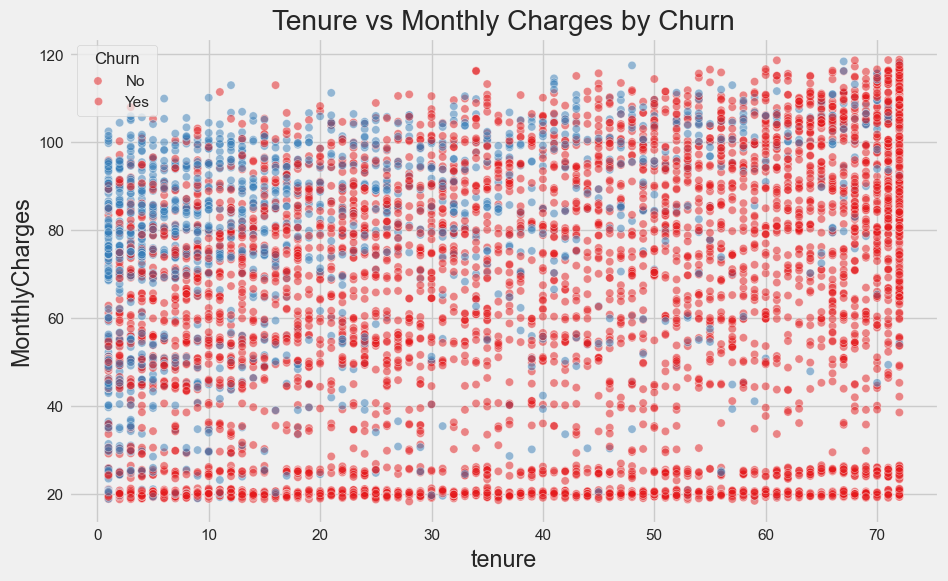

In [33]:
# Interaction: tenure × monthly charges × churn
# Hotspots: low tenure with high charges concentrate churn risk
# Action: outreach for new high-bill users; bill clarity and tailored discounts
plt.figure(figsize=(10,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, palette='Set1', alpha=0.5)
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Tenure vs Monthly Charges by Churn')
plt.show()

Quick Insight: High charges with low tenure concentrate churn risk.

#### Q10: Which services most differentiate churners from non-churners?

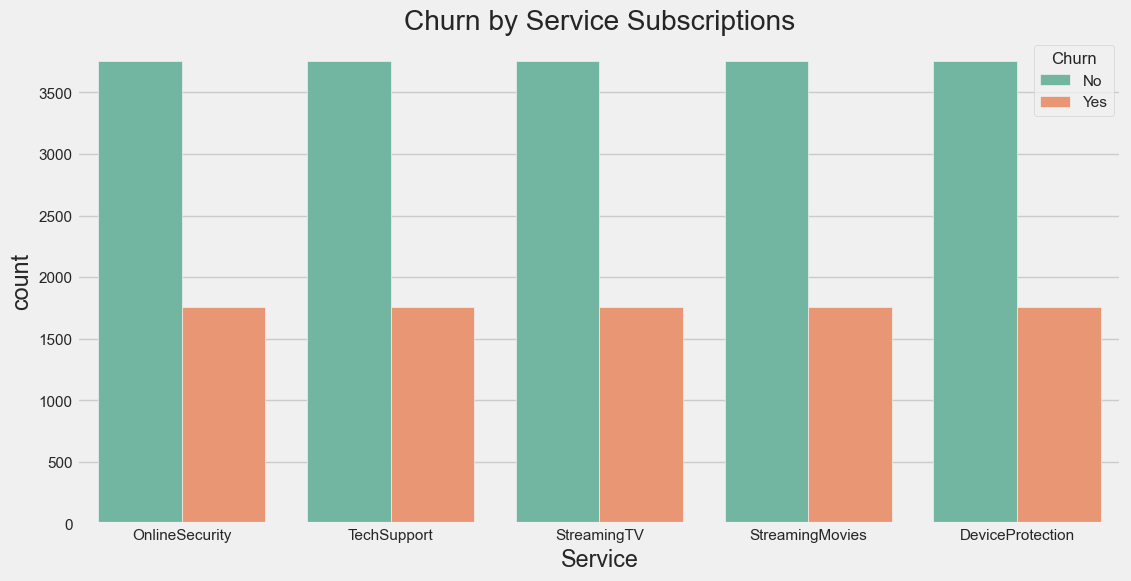

In [34]:
# Churn by service subscriptions
# Support/security reduce friction; lack of essentials increases churn risk
# Action: bundle protections; communicate benefits to shift cost→value perception
svc_cols = ['OnlineSecurity','TechSupport','StreamingTV','StreamingMovies','DeviceProtection']
df_melt = df.melt(id_vars=['Churn'], value_vars=svc_cols, var_name='Service', value_name='HasService')
df_melt = df_melt[df_melt['HasService'].isin(['Yes','No'])]
plt.figure(figsize=(12,6))
sns.countplot(x='Service', hue='Churn', data=df_melt, palette='Set2')
plt.legend(title='Churn', labels=['No','Yes'])
plt.title('Churn by Service Subscriptions')
plt.show()

Quick Insight: Lack of support/security increases churn risk; value perception matters.

## Step 8: Conclusion

### Summary of Findings
- Churn heavily concentrates among month-to-month and low-tenure customers.
- Higher monthly charges and certain service mixes (fiber optic, streaming add-ons) correlate with churn.
- Payment method matters: electronic check associates with elevated churn.

### Limitations
- Observational dataset; causality cannot be asserted without experiments.
- Potential confounding between service bundles and pricing.
- Imbalance in target classes affects recall for churners.

### Future Improvements
- Address class imbalance (SMOTE, focal loss, threshold tuning).
- Price sensitivity modeling and targeted offers for high-risk segments.
- Uplift modeling to estimate retention impact of interventions.

## Step 8: Conclusion

#### **1. Summary of Findings** 
###### **Churn concentrates** among **month-to-month** and **low-tenure** customers.  
###### **Higher MonthlyCharges** are strongly linked to churn; a T-test confirmed **significant differences** in charges between churn and non-churn groups (p < 0.001).  
###### **Electronic check** payment method associates with elevated churn; certain service mixes (e.g., **fiber optic**, streaming add-ons) correlate with churn, likely via price sensitivity.  
###### The **Random Forest Classifier** reached **~0.78 accuracy**; recall for churners is lower, reinforcing the need to optimize for minority class performance. 
 
#### **2. Limitations and Future Improvements** 
###### Observational data with potential **confounding** (bundles vs pricing); **class imbalance** reduces churn recall.  
###### Apply **SMOTE / class weights / threshold tuning**, evaluate **Logistic Regression** and **Gradient Boosting** with **cost-sensitive** objectives, and conduct **A/B tests** for retention offers.  
###### Include **cohort time-series** and **uplift modeling** to estimate the impact of interventions on retention. 
 
#### **3. Key Takeaways** 
###### To reduce churn, prioritize migrating **month-to-month** users to longer contracts, optimize **pricing** for high-risk segments, and reduce friction in **payment methods**—while targeting support/security add-ons where value perception is low.

## **PROJECT SUMMARY** 
 
### **Overview** 
 This project analyzes **telecom customer churn** using ~7k records to identify drivers of churn and build a classification model to flag high-risk customers. It includes data type corrections, categorical encoding, statistical validation, and model evaluation with business-oriented metrics. 
 
### **Key Objectives Achieved** 
 1. **Data Preprocessing**: Fixed `TotalCharges` types, dropped missing rows, removed `customerID`, applied **one-hot encoding** to categorical variables. 
 2. **Exploratory Data Analysis**: Analyzed churn distribution, contract types, monthly charges, and service-related features; built correlation heatmaps. 
 3. **Statistical Validation**: Conducted a **T-test** confirming churners have significantly higher monthly charges. 
 4. **Predictive Modeling**: Trained a **Random Forest Classifier**, evaluated accuracy and confusion matrix to assess churn recall. 
 5. **Visualization**: Delivered a Q-style set of charts to communicate segment risks and pricing effects. 
 
### **Major Findings** 
 - **Primary Risk Segments**: Month-to-month, low-tenure customers; those paying via **electronic check**. 
 - **Price Sensitivity**: Higher **MonthlyCharges** strongly associated with churn. 
 - **Service Mix**: Fiber optic and streaming add-ons align with churn—likely mediated by price. 
 - **Model Insights**: Accuracy ~0.78; minority-class recall needs improvement for operational use. 
 
### **Methodology** 
 1. Type corrections, missing value handling, encoding. 
 2. EDA with countplots, box/violin, scatter, heatmap. 
 3. T-test for charges vs churn. 
 4. Random Forest training; confusion matrix; feature importance. 
 
### **Technical Stack** 
 - **Python Libraries**: Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn 
 - **Techniques**: One-hot encoding, standardization, cross-validation, class imbalance awareness 
 
### **Business Significance** 
 Results inform **retention strategy**: migrate month-to-month to longer contracts, adjust **pricing**, and reduce friction in **payments**, while targeting support/security value perception. 
 
### **Project Impact** 
 Enables targeted outreach and pricing interventions to reduce churn and protect recurring revenue. 
 
### **Future Enhancements** 
 - Apply **SMOTE**, **class weights**, and **threshold tuning**; evaluate **Logistic Regression**, **XGBoost**. 
 - Implement **uplift modeling** and **A/B testing** for intervention effectiveness. 
 - Add **cohort time-series** to track retention over time. 
 
### **Conclusion** 
 A practical pipeline—from cleaning and EDA to statistical validation and classification—highlights actionable churn drivers and supports data-driven retention programs.